In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries imported!')

✅ Libraries imported!


In [3]:
X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()

print('✅ Data loaded!')
print(f'📊 X_train: {X_train.shape}')
print(f'📊 X_test: {X_test.shape}')
print(f'🎯 y_train: {y_train.shape}')
print(f'🎯 y_test: {y_test.shape}')

✅ Data loaded!
📊 X_train: (806, 13)
📊 X_test: (202, 13)
🎯 y_train: (806,)
🎯 y_test: (202,)


In [15]:
X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/y_test.csv').values.ravel()

print('✅ Data loaded!')
print(f'📊 X_train: {X_train.shape}')
print(f'📊 X_test: {X_test.shape}')
print(f'🎯 y_train: {y_train.shape}, unique values: {np.unique(y_train)}')
print(f'🎯 y_test: {y_test.shape}, unique values: {np.unique(y_test)}')
print(f'\nAny NaN in X_train? {X_train.isnull().sum().sum()}')
print(f'Any NaN in y_train? {pd.isnull(y_train).sum()}')

✅ Data loaded!
📊 X_train: (806, 13)
📊 X_test: (202, 13)
🎯 y_train: (806,), unique values: [0 1]
🎯 y_test: (202,), unique values: [0 1]

Any NaN in X_train? 0
Any NaN in y_train? 0


In [16]:
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)

print('📊 LOGISTIC REGRESSION RESULTS')
print(f'Accuracy:  {log_accuracy:.3f}')
print(f'Precision: {log_precision:.3f}')
print(f'Recall:    {log_recall:.3f}')
print(f'F1-Score:  {log_f1:.3f}')

📊 LOGISTIC REGRESSION RESULTS
Accuracy:  0.856
Precision: 0.847
Recall:    0.772
F1-Score:  0.808


In [5]:
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print('📊 DECISION TREE RESULTS')
print(f'Accuracy:  {dt_accuracy:.3f}')
print(f'Precision: {dt_precision:.3f}')
print(f'Recall:    {dt_recall:.3f}')
print(f'F1-Score:  {dt_f1:.3f}')

📊 DECISION TREE RESULTS
Accuracy:  0.822
Precision: 0.779
Recall:    0.759
F1-Score:  0.769


In [6]:
rf_model = RandomForestClassifier(n_estimators=100,
                                   random_state=42,
                                   max_depth=10)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print('📊 RANDOM FOREST RESULTS')
print(f'Accuracy:  {rf_accuracy:.3f}')
print(f'Precision: {rf_precision:.3f}')
print(f'Recall:    {rf_recall:.3f}')
print(f'F1-Score:  {rf_f1:.3f}')

📊 RANDOM FOREST RESULTS
Accuracy:  0.847
Precision: 0.816
Recall:    0.785
F1-Score:  0.800


In [17]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [log_accuracy, dt_accuracy, rf_accuracy],
    'Precision': [log_precision, dt_precision, rf_precision],
    'Recall': [log_recall, dt_recall, rf_recall],
    'F1-Score': [log_f1, dt_f1, rf_f1]
})

print('📊 MODEL COMPARISON')
print(results.round(3).to_string(index=False))

best_model_name = results.loc[results['F1-Score'].idxmax(), 'Model']
print(f'\n🏆 Best Model: {best_model_name}')

📊 MODEL COMPARISON
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression     0.856      0.847   0.772     0.808
      Decision Tree     0.822      0.779   0.759     0.769
      Random Forest     0.847      0.816   0.785     0.800

🏆 Best Model: Logistic Regression


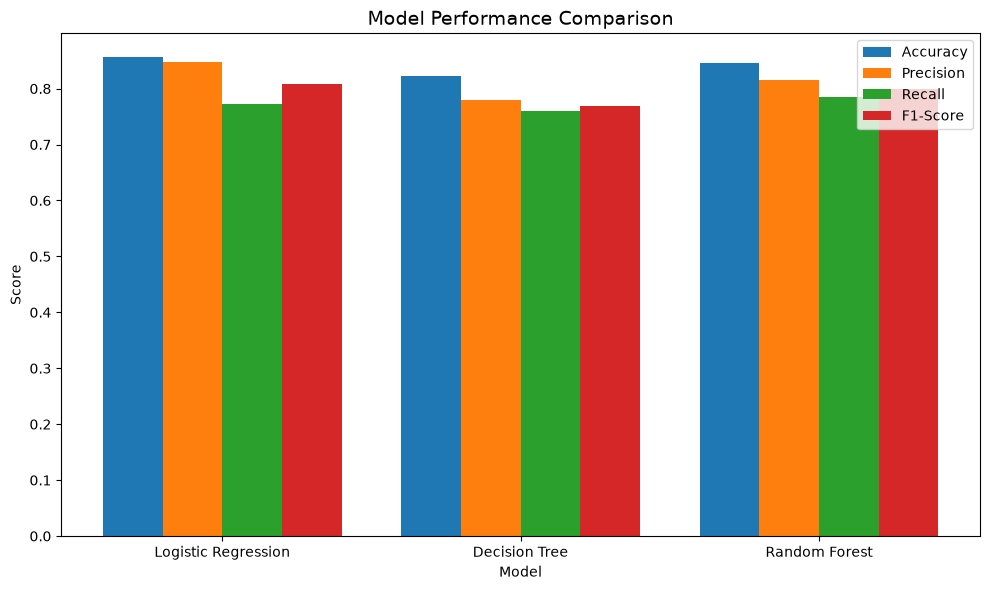

✅ Chart saved!


In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(results['Model']))
width = 0.2

ax.bar(x - 1.5*width, results['Accuracy'], width, label='Accuracy')
ax.bar(x - 0.5*width, results['Precision'], width, label='Precision')
ax.bar(x + 0.5*width, results['Recall'], width, label='Recall')
ax.bar(x + 1.5*width, results['F1-Score'], width, label='F1-Score')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(results['Model'])
ax.legend()
plt.tight_layout()
plt.savefig('../reports/model_comparison.png', dpi=150)
plt.show()
print('✅ Chart saved!')

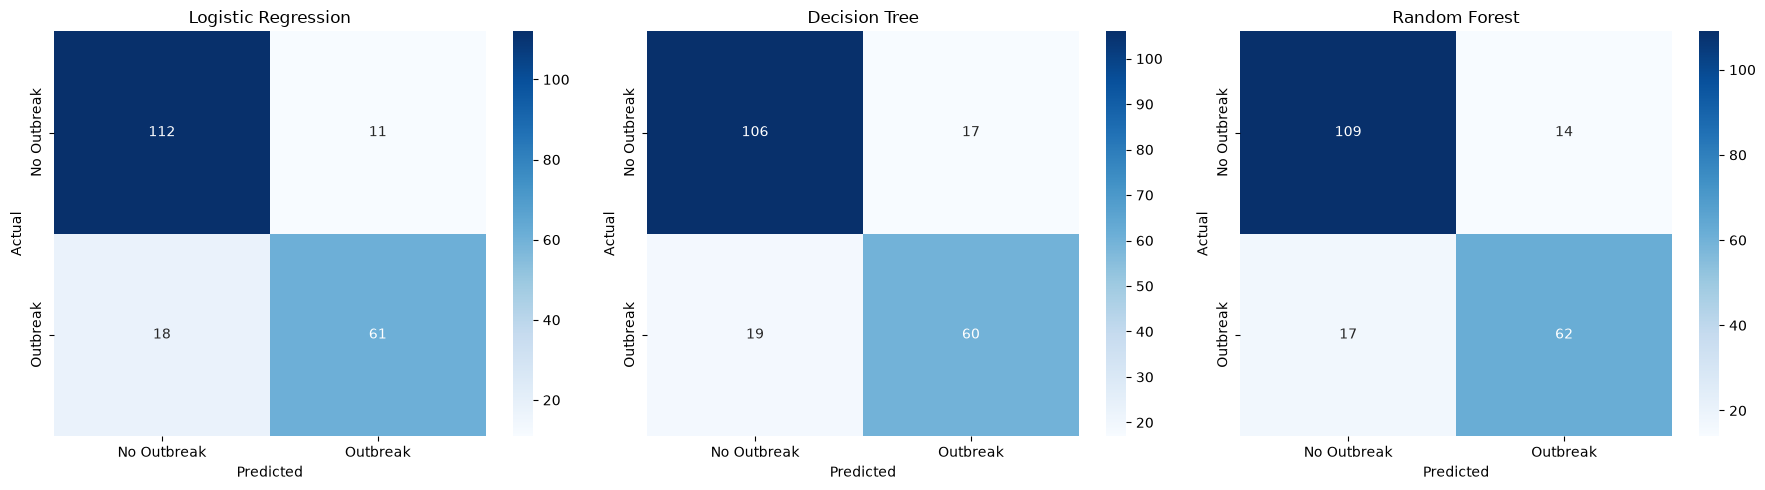

✅ Confusion matrices saved!


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_preds = [
    ('Logistic Regression', log_pred),
    ('Decision Tree', dt_pred),
    ('Random Forest', rf_pred)
]

for ax, (name, pred) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Outbreak', 'Outbreak'],
                yticklabels=['No Outbreak', 'Outbreak'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../reports/confusion_matrices.png', dpi=150)
plt.show()
print('✅ Confusion matrices saved!')

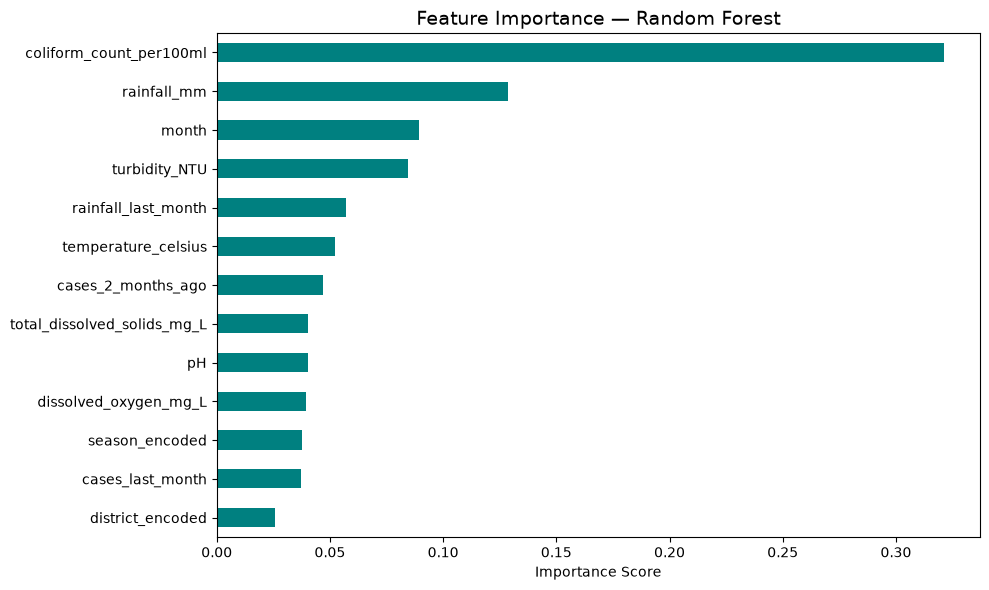

Top 5 Most Important Features:
coliform_count_per100ml    0.321
rainfall_mm                0.129
month                      0.090
turbidity_NTU              0.084
rainfall_last_month        0.057
dtype: float64


In [20]:
importances = pd.Series(rf_model.feature_importances_,
                        index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='teal')
plt.title('Feature Importance — Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=150)
plt.show()

print('Top 5 Most Important Features:')
print(importances.head(5).round(3))

In [11]:
import joblib
import os
os.makedirs('../models', exist_ok=True)

# Save Random Forest as baseline best model
joblib.dump(rf_model, '../models/baseline_model.pkl')

print('✅ Baseline model saved: models/baseline_model.pkl')
print(f'🏆 Random Forest F1-Score: {rf_f1:.3f}')
print('\n🚀 Ready for hyperparameter tuning tomorrow!')

✅ Baseline model saved: models/baseline_model.pkl
🏆 Random Forest F1-Score: 0.800

🚀 Ready for hyperparameter tuning tomorrow!


In [12]:
print("Feature columns used:")
print(X_train.columns.tolist())
print("\nIs 'total_disease_cases' or related case columns in features?")
leak_check = [col for col in X_train.columns if 'cases' in col.lower() or 'outbreak' in col.lower()]
print(leak_check)

Feature columns used:
['rainfall_mm', 'temperature_celsius', 'pH', 'turbidity_NTU', 'coliform_count_per100ml', 'dissolved_oxygen_mg_L', 'total_dissolved_solids_mg_L', 'month', 'district_encoded', 'season_encoded', 'cases_last_month', 'cases_2_months_ago', 'rainfall_last_month']

Is 'total_disease_cases' or related case columns in features?
['cases_last_month', 'cases_2_months_ago']


In [13]:
# Check correlation of raw features with outbreak_alert
df_check = pd.read_csv('../data/processed_data.csv')
check_cols = ['turbidity_NTU', 'coliform_count_per100ml', 'rainfall_mm', 'temperature_celsius', 'outbreak_alert']
print(df_check[check_cols].corr()['outbreak_alert'])

turbidity_NTU              0.326953
coliform_count_per100ml    0.650817
rainfall_mm                0.493951
temperature_celsius        0.082602
outbreak_alert             1.000000
Name: outbreak_alert, dtype: float64


In [14]:
df_check = pd.read_csv('../data/processed_data.csv')
print("Columns in processed_data.csv:")
print(df_check.columns.tolist())
print("\nShape:", df_check.shape)
print("\nFirst row:")
print(df_check.head(1))

Columns in processed_data.csv:
['date', 'year', 'month', 'month_name', 'district', 'rainfall_mm', 'temperature_celsius', 'pH', 'turbidity_NTU', 'coliform_count_per100ml', 'dissolved_oxygen_mg_L', 'total_dissolved_solids_mg_L', 'population', 'cholera_cases', 'diarrhea_cases', 'typhoid_cases', 'hepatitis_a_cases', 'total_disease_cases', 'outbreak_alert', 'season', 'cases_last_month', 'cases_2_months_ago', 'rainfall_last_month', 'district_encoded', 'season_encoded']

Shape: (1008, 25)

First row:
         date  year  month month_name district  rainfall_mm  \
0  2018-01-01  2018      1    January  Chennai         25.6   

   temperature_celsius    pH  turbidity_NTU  coliform_count_per100ml  ...  \
0                37.31  7.88            9.9                    43.69  ...   

   typhoid_cases  hepatitis_a_cases  total_disease_cases  outbreak_alert  \
0              8                  7                  104               0   

   season  cases_last_month  cases_2_months_ago  rainfall_last_mon

In [ ]:
check_cols = ['turbidity_NTU', 'coliform_count_per100ml', 'rainfall_mm', 'temperature_celsius', 'outbreak_alert']
print(df_check[check_cols].corr()['outbreak_alert'])

In [ ]:
print("Data types:")
print(df_check[check_cols].dtypes)
print("\nAny NaN values in these columns?")
print(df_check[check_cols].isnull().sum())
print("\nStandard deviation (0 = no variance = NaN correlation):")
print(df_check[check_cols].std())